In [6]:
"""from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()"""

'from google.colab import files\nimport pandas as pd\n\n# Upload file\nuploaded = files.upload()'

In [7]:
import pandas as pd
df = pd.read_csv('heart.csv')

print(df)
print(df.head)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2   2     3       0  
1         0

In [8]:

# --- STEP 1: Install and Import ---
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("All imports done ✓")

All imports done ✓


In [9]:
# --- STEP 2: Load the Data ---
# Upload heart.csv to Colab first, then run this

df = pd.read_csv('heart.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
# --- STEP 3: EDA (Exploratory Data Analysis) ---
# Always do this first — understand your data before touching it

print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution ===")
print(df['target'].value_counts())
# target: 1 = has heart disease, 0 = no heart disease

print("\n=== Basic Stats ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


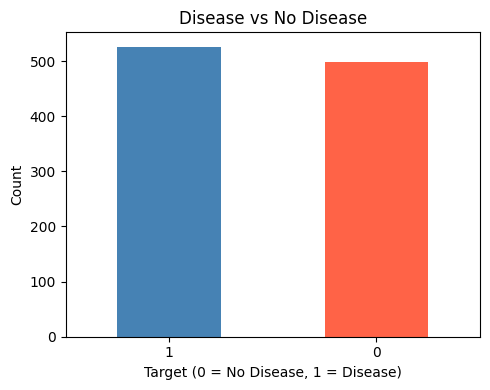

In [11]:
# Visualize class distribution
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Disease vs No Disease')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

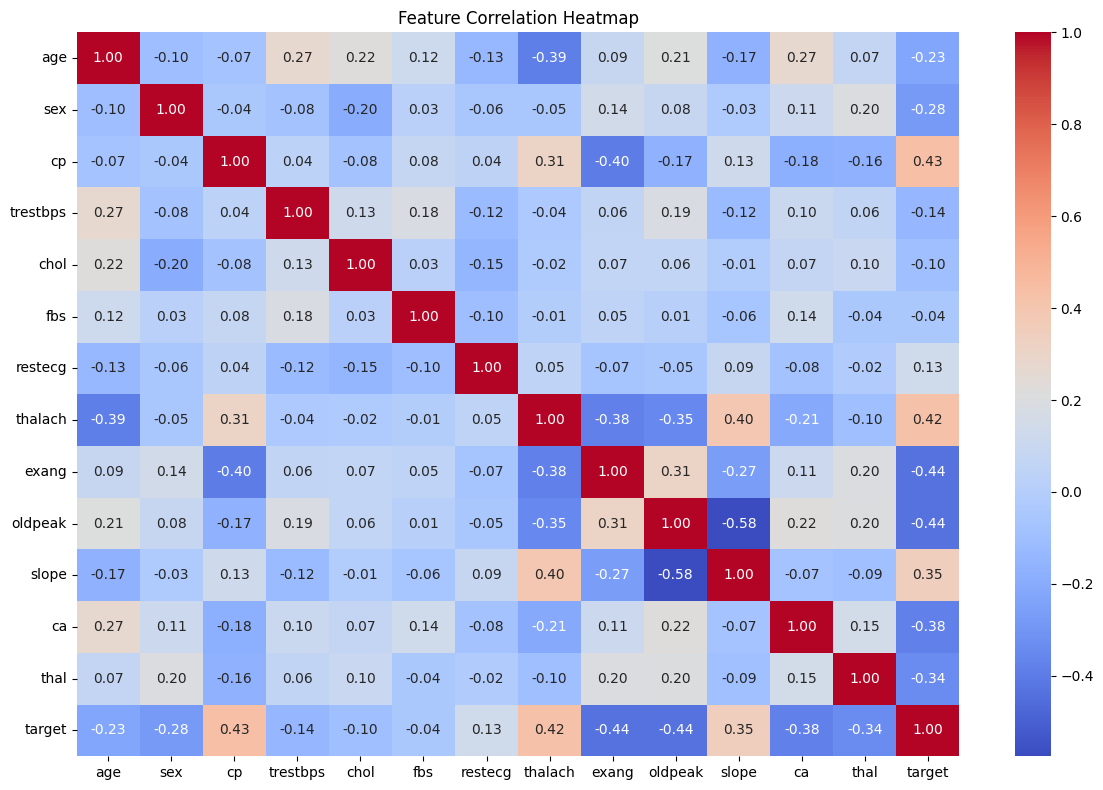

In [12]:
# Correlation heatmap — see which features matter
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
# --- STEP 4: Preprocessing ---

# Check the columns
print(df.columns.tolist())

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Features shape: (1025, 13)
Target shape: (1025,)


In [14]:
# Fixed models with regularization

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,        # limit tree depth
        min_samples_split=10,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        max_depth=3,        # shallower trees
        learning_rate=0.1,
        n_estimators=100,
        subsample=0.8,      # use 80% of data per tree
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

In [15]:
# Train/Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y makes sure both splits have similar class ratios

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (820, 13)
Test size: (205, 13)


In [16]:
# Feature Scaling — important for SVM and Logistic Regression
# Tree-based models (RF, XGBoost) don't need this but it doesn't hurt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# fit on train only — never fit on test data (data leakage)

print("Scaling done ✓")

Scaling done ✓


In [17]:
# --- STEP 5: Train Multiple Models ---

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for LR and SVM, unscaled for tree models
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy  : {results[name]['Accuracy']:.4f}")
    print(f"Precision : {results[name]['Precision']:.4f}")
    print(f"Recall    : {results[name]['Recall']:.4f}")
    print(f"F1 Score  : {results[name]['F1']:.4f}")
    print(f"ROC-AUC   : {results[name]['ROC-AUC']:.4f}")


=== Logistic Regression ===
Accuracy  : 0.8098
Precision : 0.7619
Recall    : 0.9143
F1 Score  : 0.8312
ROC-AUC   : 0.9298

=== SVM ===
Accuracy  : 0.9268
Precision : 0.9167
Recall    : 0.9429
F1 Score  : 0.9296
ROC-AUC   : 0.9771

=== Random Forest ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

=== XGBoost ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000


In [18]:
# --- STEP 6: Comparison Table ---

results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, vals in results.items()
}).T

print("\n=== Model Comparison ===")
print(results_df.round(4).to_string())


=== Model Comparison ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8098     0.7619  0.9143  0.8312   0.9298
SVM                    0.9268     0.9167  0.9429  0.9296   0.9771
Random Forest          1.0000     1.0000  1.0000  1.0000   1.0000
XGBoost                1.0000     1.0000  1.0000  1.0000   1.0000


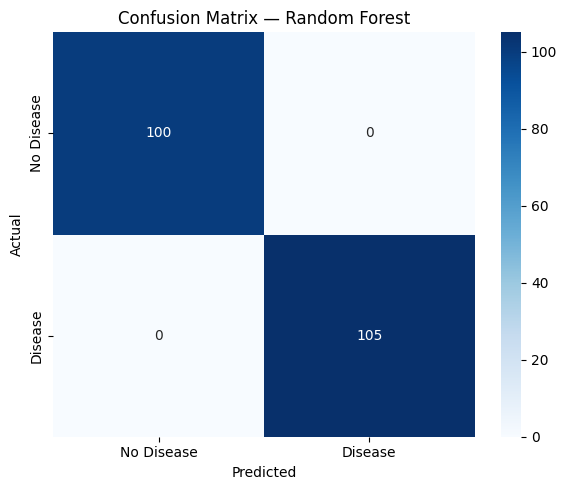


Classification Report — Random Forest
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [19]:
# --- STEP 7: Confusion Matrix for best model ---
# Let's say Random Forest or XGBoost tends to win — adjust as per your results

best_model_name = "Random Forest"  # change this based on your results

cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_model_name}")
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['No Disease', 'Disease']))

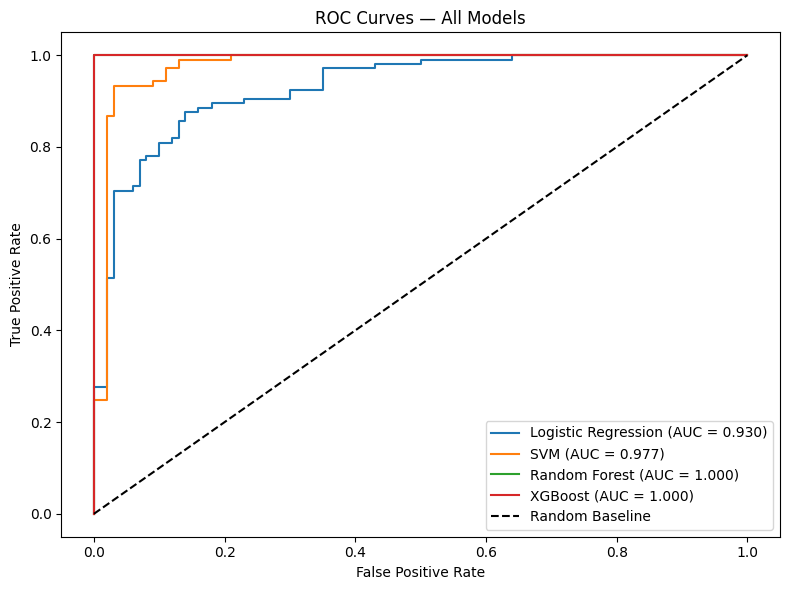

In [20]:
# --- STEP 8: ROC Curve for all models ---

plt.figure(figsize=(8, 6))

for name, vals in results.items():
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {vals['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

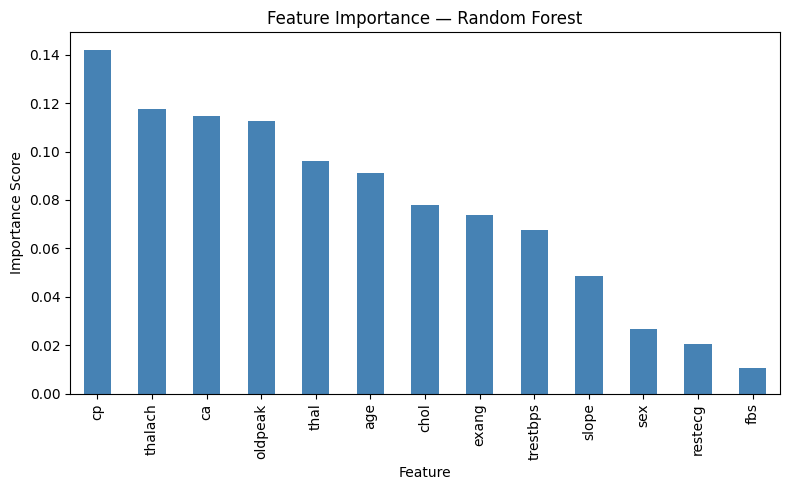

In [21]:
# --- STEP 9: Feature Importance (Random Forest) ---

rf_model = results["Random Forest"]["model"]

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp_sorted.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

In [22]:
# --- STEP 10: Save the best model ---

import joblib

best_model = results["Random Forest"]["model"]  # change as needed
joblib.dump(best_model, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as heart_disease_model.pkl ✓")
print("Scaler saved as scaler.pkl ✓")

Model saved as heart_disease_model.pkl ✓
Scaler saved as scaler.pkl ✓


In [23]:
# --- BONUS: Predict on new patient data ---

# Example: a new patient's data (same column order as dataset)
new_patient = pd.DataFrame([[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]],
                            columns=X.columns)

# Scale it
new_patient_scaled = scaler.transform(new_patient)

# Predict using LR or SVM (scaled), RF/XGB (unscaled)
rf_pred = results["Random Forest"]["model"].predict(new_patient)[0]
rf_prob = results["Random Forest"]["model"].predict_proba(new_patient)[0][1]

print(f"Prediction: {'Heart Disease' if rf_pred == 1 else 'No Heart Disease'}")
print(f"Probability of Disease: {rf_prob:.2%}")

Prediction: No Heart Disease
Probability of Disease: 3.00%


In [24]:
# Check training data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
df = pd.read_csv('heart.csv')
print(df.head())
print(df.columns)
print(df['target'].value_counts())  # How many disease vs no disease?

# Check model performance
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
target
1    526
0    499
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    acc

In [25]:
# Recreate X_test and y_test from your data
df = pd.read_csv('heart.csv')

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)

print(f"No disease samples in test: {sum(y_test == 0)}")
print(f"Model predicted no disease: {sum(y_pred == 0)}")
print(f"Disease samples in test: {sum(y_test == 1)}")
print(f"Model predicted disease: {sum(y_pred == 1)}")

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

No disease samples in test: 100
Model predicted no disease: 43
Disease samples in test: 105
Model predicted disease: 162
              precision    recall  f1-score   support

           0       0.79      0.34      0.48       100
           1       0.59      0.91      0.72       105

    accuracy                           0.63       205
   macro avg       0.69      0.63      0.60       205
weighted avg       0.69      0.63      0.60       205



In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import joblib

# Retrain with proper parameters on RAW data (no scaling)
best_model = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=0.95,
    eval_metric='logloss',
    random_state=42
)

best_model.fit(X_train, y_train)  # raw X_train, NOT X_train_scaled

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

joblib.dump(best_model, 'heart_disease_model.pkl')
print("Model saved ✓")

              precision    recall  f1-score   support

  No Disease       0.98      0.98      0.98       100
     Disease       0.98      0.98      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205

Model saved ✓


In [27]:
import joblib

# Save the trained model
joblib.dump(model, "heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!
